In [1]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from gsplat import rasterization
from plyfile import PlyData
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt

In [2]:
def load_gsplat_ply(ply_path):
    plydata = PlyData.read(ply_path)
    v = plydata["vertex"].data
    print("Loaded", len(v), "points from", ply_path)

    means = np.stack([v["x"], v["y"], v["z"]], axis=1)
    scales = np.exp(np.stack([v["scale_0"], v["scale_1"], v["scale_2"]], axis=1))
    quats = np.stack([v["rot_0"], v["rot_1"], v["rot_2"], v["rot_3"]], axis=1)
    opacities = 1 / (1 + np.exp(-np.asarray(v["opacity"], np.float32)))
    colors = np.empty((len(v), 16, 3), np.float32)
    colors[:, 0, :] = np.stack([v["f_dc_0"], v["f_dc_1"], v["f_dc_2"]], axis=1)
    rest_coeffs = np.stack([v[f"f_rest_{i}"] for i in range(45)], axis=1)
    colors[:, 1:, 0] = rest_coeffs[:, 0:15]
    colors[:, 1:, 1] = rest_coeffs[:, 15:30]
    colors[:, 1:, 2] = rest_coeffs[:, 30:45]

    return means, quats, scales, opacities, colors

def create_gsplat_model(ply_path, width, height, K, device="cuda"):
    # Load Gaussian Splatting data
    means, quats, scales, opacities, colors = load_gsplat_ply(ply_path)

    # Convert to torch tensors
    means = torch.tensor(means, dtype=torch.float32, device=device, requires_grad=False)
    quats = torch.tensor(quats, dtype=torch.float32, device=device, requires_grad=False)
    quats = F.normalize(quats, p=2, dim=-1) # Ensure quaternions are normalized
    scales = torch.tensor(scales, dtype=torch.float32, device=device, requires_grad=False)
    opacities = torch.tensor(opacities, dtype=torch.float32, device=device, requires_grad=False)
    colors = torch.tensor(colors, dtype=torch.float32, device=device, requires_grad=False)
    Ks = torch.tensor(K, dtype=torch.float32, device=device)
    # OpenCV to North-West-Up coordinate system
    opencv2NWU = torch.tensor([[ 0,  0, 1, 0],
                               [-1,  0, 0, 0],
                               [ 0, -1, 0, 0],
                               [ 0,  0, 0, 1]], dtype=torch.float32, device=device)
    def model_fn(cam_pose: torch.Tensor):
        '''[C,4,4] in Z-up coordinate system'''
        cam_pose = cam_pose @ opencv2NWU
        num_cam = cam_pose.shape[0]
        viewmats = torch.linalg.inv(cam_pose)  # [C,4,4]
        Ks_expanded = Ks.expand(num_cam, 3, 3)  # [C,3,3]
        return rasterization(
            means=means.unsqueeze(0),
            quats=quats.unsqueeze(0),
            scales=scales.unsqueeze(0),
            opacities=opacities.unsqueeze(0),
            colors=colors.unsqueeze(0),
            viewmats=viewmats.unsqueeze(0),
            Ks=Ks_expanded.unsqueeze(0),
            width=width,
            height=height,
            sh_degree=3,
            render_mode="RGB",
            rasterize_mode="antialiased",
            camera_model="pinhole",
            near_plane=0.001,
            far_plane=100.0,
            tile_size=8,
        )[0].squeeze(0)
    return model_fn

In [3]:
# Gaussian Splatting model for the track
# gsplat_ply_file: str = os.path.abspath(os.path.join("gsplat", "arms_lab.ply"))  # Path to the GSPLAT .ply file for the track
gsplat_ply_file: str = os.path.abspath("arms_lab.ply") # Path to the GSPLAT .ply file for the track

render_res = (64, 64)  # Resolution for the GSPLAT rendering (width, height)
focal_length = 36.5 * (render_res[0] / 64)  # Focal length for the GSPLAT rendering, in pixels
camera_intrinsics = (
    [
        [focal_length, 0, render_res[0] // 2],
        [0, focal_length, render_res[1] // 2],
        [0, 0, 1],
    ],
)
model = create_gsplat_model(
    gsplat_ply_file, width=render_res[0], height=render_res[1], K=camera_intrinsics
)

Loaded 437308 points from /home/isaac/cf-frame-extrap/arms_lab.ply


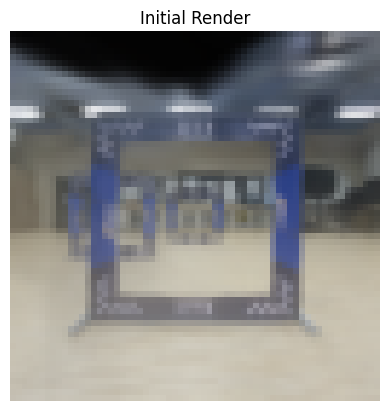

In [4]:
# Initial camera pose (4x4 matrix)
position = np.array([-1.0, -0.5, 0.5])
orientation = Rotation.from_euler('xyz', (0, 0, 0), degrees=True).as_matrix() # RPY in the order applied as Yaw->pitch->roll
initial_cam_pose = np.eye(4, dtype=np.float32)
initial_cam_pose[:3, :3] = orientation
initial_cam_pose[:3, 3] = position
initial_cam_pose = torch.tensor(initial_cam_pose, dtype=torch.float32).to("cuda")
initial_cam_pose = initial_cam_pose.unsqueeze(0)
# Render
img = model(initial_cam_pose).squeeze(0).detach().cpu().numpy()
plt.imshow(img)
plt.title(f"Initial Render")
plt.axis("off")
plt.show()

In [ ]:
# Load trajectory CSVs from capture.zip and build [N,4,4] pose matrices
import zipfile
from pathlib import Path

def _normalize(v: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    n = np.linalg.norm(v)
    if n < eps:
        return v * 0.0
    return v / n

def pose_from_pos_axes(pos_xyz: np.ndarray, x_axis: np.ndarray, y_axis: np.ndarray, z_axis: np.ndarray | None = None) -> np.ndarray:
    """Return T_world_body (4x4) from position and body axes expressed in world frame.

    CSV provides body x/y/z axes in world coordinates (orn1/orn2/orn3).
    We re-orthonormalize for numerical stability.
    """
    x = _normalize(x_axis.astype(np.float32))
    y = y_axis.astype(np.float32)
    y = y - x * float(np.dot(x, y))
    y = _normalize(y)

    z = np.cross(x, y)
    z = _normalize(z)
    y = np.cross(z, x)
    y = _normalize(y)

    R = np.stack([x, y, z], axis=1)  # columns are body axes in world frame
    if np.linalg.det(R) < 0:
        # fix reflection if it happens
        R[:, 2] *= -1.0

    T = np.eye(4, dtype=np.float32)
    T[:3, :3] = R
    T[:3, 3] = pos_xyz.astype(np.float32)
    return T

def load_capture_poses(capture_zip: str = "capture.zip", out_dir: str = "capture_data"):
    out_dir_p = Path(out_dir)
    if not out_dir_p.exists():
        out_dir_p.mkdir(parents=True, exist_ok=True)
        print(f"Extracted {capture_zip} to {out_dir_p.resolve()}")
        with zipfile.ZipFile(capture_zip, "r") as zf:
            zf.extractall(out_dir_p)

    csvs = sorted(out_dir_p.glob("capture_*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No capture_*.csv files found in {out_dir_p.resolve()}")

    all_poses = {}
    for csv_path in csvs:
        data = np.genfromtxt(csv_path, delimiter=",", names=True, dtype=np.float32)

        # expected columns: pos_x,pos_y,pos_z, orn1_*, orn2_*, orn3_*
        pos = np.stack([data["pos_x"], data["pos_y"], data["pos_z"]], axis=1)
        xax = np.stack([data["orn1_x"], data["orn1_y"], data["orn1_z"]], axis=1)
        yax = np.stack([data["orn2_x"], data["orn2_y"], data["orn2_z"]], axis=1)
        zax = np.stack([data["orn3_x"], data["orn3_y"], data["orn3_z"]], axis=1)

        poses = np.stack([pose_from_pos_axes(pos[i], xax[i], yax[i], zax[i]) for i in range(pos.shape[0])], axis=0)
        all_poses[csv_path.stem] = poses

    return all_poses

capture_poses = load_capture_poses("./data/capture.zip", "./data/csv")
print("loaded trajectories:", list(capture_poses.keys())[:5], "... total", len(capture_poses))
first_key = sorted(capture_poses.keys())[0]
poses_np = capture_poses[first_key]
print(first_key, "poses:", poses_np.shape, "example det(R):", np.linalg.det(poses_np[0, :3, :3]))

# Convert to torch for rendering/training
poses = torch.tensor(poses_np, dtype=torch.float32, device="cuda")  # [N,4,4]


False /home/isaac/cf-frame-extrap/data/csv
Extracted ./data/capture.zip to /home/isaac/cf-frame-extrap/data/csv
loaded trajectories: ['capture_kinematics_0', 'capture_kinematics_1', 'capture_kinematics_10', 'capture_kinematics_11', 'capture_kinematics_12'] ... total 53
capture_kinematics_0 poses: (244, 4, 4) example det(R): 1.0


In [23]:
# Render and save frames for ALL trajectories in capture_poses
import os

base_dir = "./data/renders"
os.makedirs(base_dir, exist_ok=True)

for key in sorted(capture_poses.keys()):
    poses_np = capture_poses[key]
    poses = torch.tensor(poses_np, dtype=torch.float32, device="cuda")  # [N,4,4]

    out_dir = os.path.join(base_dir, f"renders_{key}")
    os.makedirs(out_dir, exist_ok=True)

    for i in range(poses.shape[0]):
        cam_pose = poses[i : i + 1]  # [1,4,4]
        img = model(cam_pose).squeeze(0).detach().cpu().numpy()
        img = np.clip(img, 0, 1)
        plt.imsave(os.path.join(out_dir, f"render_{i:04d}.png"), img)

    print("saved", key, "to", out_dir)

saved capture_kinematics_0 to ./data/renders/renders_capture_kinematics_0
saved capture_kinematics_1 to ./data/renders/renders_capture_kinematics_1
saved capture_kinematics_10 to ./data/renders/renders_capture_kinematics_10
saved capture_kinematics_11 to ./data/renders/renders_capture_kinematics_11
saved capture_kinematics_12 to ./data/renders/renders_capture_kinematics_12
saved capture_kinematics_13 to ./data/renders/renders_capture_kinematics_13
saved capture_kinematics_14 to ./data/renders/renders_capture_kinematics_14
saved capture_kinematics_15 to ./data/renders/renders_capture_kinematics_15
saved capture_kinematics_16 to ./data/renders/renders_capture_kinematics_16
saved capture_kinematics_17 to ./data/renders/renders_capture_kinematics_17
saved capture_kinematics_18 to ./data/renders/renders_capture_kinematics_18
saved capture_kinematics_19 to ./data/renders/renders_capture_kinematics_19
saved capture_kinematics_2 to ./data/renders/renders_capture_kinematics_2
saved capture_kine